# Dự báo mức độ nhu cầu thuê xe đạp (Bike Sharing) — Classification

Bộ dữ liệu `hour.csv` (UCI Bike Sharing, số lượt thuê xe theo giờ, 2011–2012). Bài toán: phân loại mức độ nhu cầu của mỗi giờ thành 3 lớp **thấp / vừa / cao** dựa trên `cnt`.

## Thiết lập & load dữ liệu

Dữ liệu được sort theo (`dteday`, `hr`) ngay khi load vì mọi bước sau (chia theo thời gian, lag) đều phụ thuộc vào thứ tự thời gian. Sửa `DATA_PATH` nếu file nằm ở thư mục khác.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

seed = 42
DATA_PATH = "hour.csv"
TEST_SIZE = 0.2
VAL_SIZE = 0.2
DEMAND_LEVEL_LABELS = {0: "low", 1: "medium", 2: "high"}
CYCLICAL_FEATURES = {"hr": 24, "mnth": 12, "weekday": 7}
ONE_HOT_FEATURES = ["season", "weathersit"]

In [2]:
df = pd.read_csv(DATA_PATH)
df["dteday"] = pd.to_datetime(df["dteday"])
df = df.sort_values(["dteday", "hr"]).reset_index(drop=True)
print("Shape:", df.shape)
df.head()

Shape: (17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


# Phần A — EDA

## A1. Sanity check

Kiểm tra dữ liệu có "sạch" và đúng như mô tả trong `Readme.txt` không: kiểu dữ liệu, giá trị thiếu, dòng trùng lặp, ràng buộc `casual + registered = cnt`, miền giá trị và tính liên tục theo thời gian.

In [3]:
print(df.dtypes, end="\n\n")
print("Missing values per column:")
print(df.isna().sum(), end="\n\n")
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate (dteday, hr):", df.duplicated(subset=["dteday", "hr"]).sum())
print("Rows where casual + registered != cnt:", (df["casual"] + df["registered"] != df["cnt"]).sum(), end="\n\n")

range_checks = {
    "season": (1, 4), "weathersit": (1, 4), "hr": (0, 23), "weekday": (0, 6),
    "mnth": (1, 12), "holiday": (0, 1), "workingday": (0, 1), "yr": (0, 1),
}
for col, (lo, hi) in range_checks.items():
    print(f"{col:12s} valid range [{lo},{hi}] -> out-of-range rows: {((df[col] < lo) | (df[col] > hi)).sum()}")
print()
for col in ["temp", "atemp", "hum", "windspeed"]:
    print(f"{col:10s} min={df[col].min():.4f}  max={df[col].max():.4f}")
print()

full_dt = df["dteday"] + pd.to_timedelta(df["hr"], unit="h")
full_range = pd.date_range(df["dteday"].min(), df["dteday"].max() + pd.Timedelta(hours=23), freq="h")
missing_hours = full_range.difference(full_dt)
print("Date range:", df["dteday"].min().date(), "->", df["dteday"].max().date())
print("Expected hours:", len(full_range), "| Actual rows:", len(df), "| Missing hours:", len(missing_hours))

instant                int64
dteday        datetime64[us]
season                 int64
yr                     int64
mnth                   int64
hr                     int64
holiday                int64
weekday                int64
workingday             int64
weathersit             int64
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
casual                 int64
registered             int64
cnt                    int64
dtype: object

Missing values per column:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Duplicate rows: 0
Duplicate (dteday, hr): 0
Rows where casual + registered != cnt: 0

season       valid range [1,4] -> out-of-range rows: 0
weathersit   valid range [1,4] -> out-

**Nhận xét sanity check:**
- Không có NaN, không có dòng trùng lặp — đúng như dự kiến.
- `casual + registered = cnt` khớp 100% — dữ liệu đáng tin cậy.
- Tất cả cột hạng mục/nhị phân đều nằm đúng miền mô tả trong `Readme.txt`; các cột chuẩn hoá (`temp`, `atemp`, `hum`, `windspeed`) đều trong [0, 1].
- 165 giờ bị thiếu trong chuỗi thời gian (2 năm 2011–2012) — không phải lỗi cần sửa nhưng phải ghi vào báo cáo và lưu ý khi làm feature time-series (lag, rolling).

→ Kết luận: dữ liệu sạch, sẵn sàng cho các bước tiếp theo.

## A2. Chia tập theo thời gian và định nghĩa nhãn mục tiêu

Vì là chuỗi thời gian, dữ liệu được chia **tuần tự** (đã sort theo `dteday`, `hr`, cắt theo tỉ lệ 60/20/20), không chia ngẫu nhiên, để tránh rò rỉ thông tin tương lai vào tập train.

Ngưỡng phân lớp tính **một lần duy nhất trên `train_df`** bằng quantile 33% / 67% của `cnt`: `cnt <= low` → thấp (0), `cnt <= high` → vừa (1), còn lại → cao (2). Chia theo quantile thay vì ngưỡng cố định để 3 lớp xấp xỉ cân bằng.

In [4]:
n = len(df)
n_test = int(n * TEST_SIZE)
n_val = int(n * VAL_SIZE)
n_train = n - n_test - n_val

train_df = df.iloc[:n_train].copy()
for name, part in [("train", train_df), ("val", df.iloc[n_train:n_train + n_val]), ("test", df.iloc[n_train + n_val:])]:
    print(f"{name:5s}: {len(part)} rows | {part['dteday'].min().date()} -> {part['dteday'].max().date()}")

train: 10429 rows | 2011-01-01 -> 2012-03-15
val  : 3475 rows | 2012-03-15 -> 2012-08-07
test : 3475 rows | 2012-08-07 -> 2012-12-31


In [5]:
low = train_df["cnt"].quantile(0.33)
high = train_df["cnt"].quantile(0.67)
print("low =", low, "| high =", high)

def assign_demand_level(cnt):
    if cnt <= low:
        return 0
    elif cnt <= high:
        return 1
    else:
        return 2

train_df["demand_level"] = train_df["cnt"].apply(assign_demand_level)
train_df["demand_level"].map(DEMAND_LEVEL_LABELS).value_counts()

low = 56.0 | high = 176.0


demand_level
medium    3539
low       3459
high      3431
Name: count, dtype: int64

## A3. Khám phá dữ liệu (trên `train_df`)

Chỉ "nhìn" vào tập train để tránh rò rỉ thông tin từ val/test.

,cnt,casual,registered,temp,atemp,hum,windspeed
count,10429.000000,10429.000000,10429.000000,10429.000000,10429.000000,10429.000000,10429.000000
mean,144.821364,26.341164,118.480199,0.459726,0.442693,0.630609,0.195566
std,134.619510,37.208306,112.645389,0.197397,0.177321,0.197797,0.125688
min,1.000000,0.000000,0.000000,0.020000,0.000000,0.000000,0.000000
25%,32.000000,3.000000,27.000000,0.300000,0.303000,0.470000,0.104500
50%,111.000000,12.000000,93.000000,0.440000,0.439400,0.620000,0.194000
75%,213.000000,34.000000,171.000000,0.620000,0.590900,0.790000,0.283600
max,782.000000,272.000000,647.000000,0.960000,1.000000,1.000000,0.850700


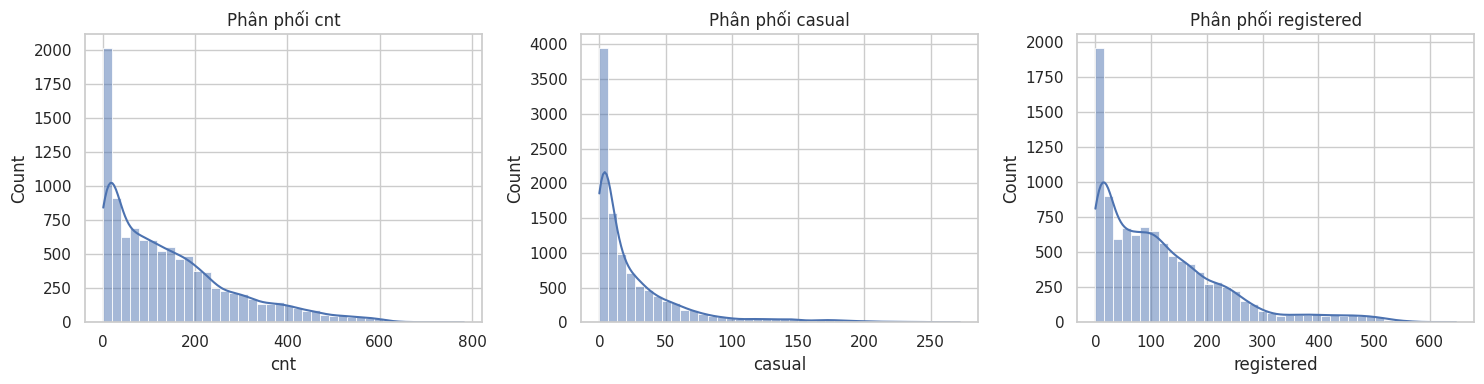

In [6]:
display(train_df[["cnt", "casual", "registered", "temp", "atemp", "hum", "windspeed"]].describe())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["cnt", "casual", "registered"]):
    sns.histplot(train_df[col], bins=40, ax=ax, kde=True)
    ax.set_title(f"Phân phối {col}")
plt.tight_layout()
plt.show()

### A3.1. Pattern theo giờ trong ngày — tách ngày làm việc / cuối tuần

So sánh hành vi người dùng **casual** (thường đi chơi/giải trí) và **registered** (thường đi làm) theo từng giờ, tách riêng `workingday` để thấy 2 kiểu pattern khác nhau.

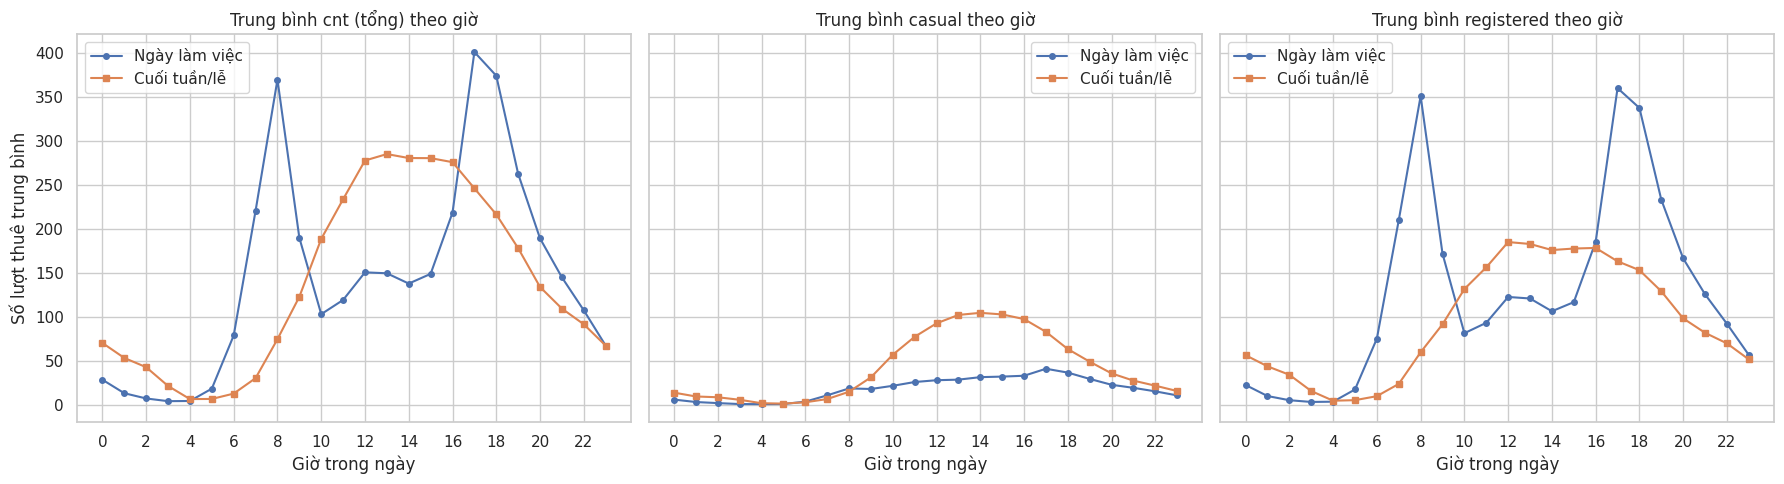

In [7]:
hourly = train_df.groupby(["workingday", "hr"])[["cnt", "casual", "registered"]].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, col, title in zip(axes, ["cnt", "casual", "registered"], ["cnt (tổng)", "casual", "registered"]):
    for wd, label, style in [(1, "Ngày làm việc", "-o"), (0, "Cuối tuần/lễ", "-s")]:
        sub = hourly[hourly["workingday"] == wd]
        ax.plot(sub["hr"], sub[col], style, label=label, markersize=4)
    ax.set_title(f"Trung bình {title} theo giờ")
    ax.set_xlabel("Giờ trong ngày")
    ax.set_xticks(range(0, 24, 2))
    ax.legend()
axes[0].set_ylabel("Số lượt thuê trung bình")
plt.tight_layout()
plt.show()

**Nhận xét** (số liệu là trung bình theo giờ trên `train_df`):

- **cnt (tổng):** ngày làm việc có 2 đỉnh rõ rệt — ~8h (≈370) và ~17h (≈400, đỉnh cao nhất trong ngày); cuối tuần/lễ chỉ có 1 đỉnh thoải quanh 12h–15h (≈285).
- **casual:** đường cuối tuần/lễ cao hơn hẳn ngày làm việc ở mọi giờ từ 10h–18h (đỉnh cuối tuần ≈105 lúc ~14h, trong khi đỉnh ngày làm việc chỉ ≈41) — đúng như dự đoán, khách casual đi chơi/giải trí nên tập trung cuối tuần, ban ngày.
- **registered:** gần như bản sao của đường `cnt` — 2 đỉnh giờ đi làm/tan làm ở ngày làm việc (≈350 lúc 8h, ≈360 lúc 17h), còn cuối tuần phẳng hơn, đỉnh ≈185 quanh 12h.

→ Bằng chứng cho nhận xét "2 nhóm người dùng có mục đích khác nhau": registered = đi làm (commute), casual = giải trí (leisure). Vì registered chiếm tỷ trọng lớn trong `cnt` nên đường `cnt` gần giống đường registered.

### A3.2. Phân bố các feature quan trọng theo từng lớp nhu cầu

Xem feature nào tách 3 lớp (thấp/vừa/cao) rõ nhất.

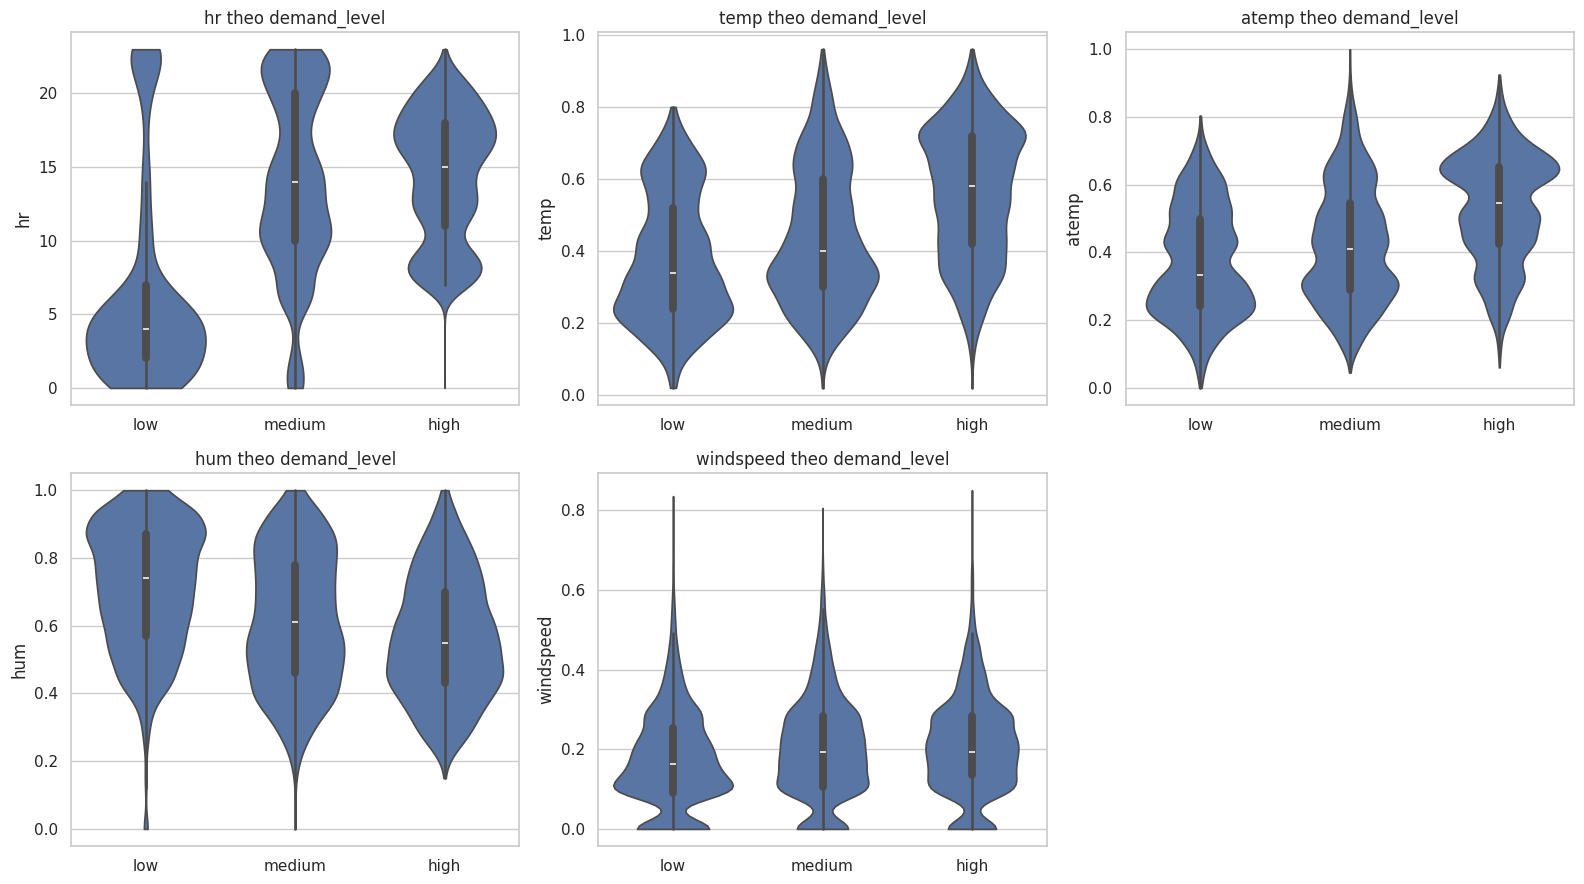

In [8]:
label_names = list(DEMAND_LEVEL_LABELS.values())
plot_df = train_df.assign(demand_label=train_df["demand_level"].map(DEMAND_LEVEL_LABELS))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, feat in zip(axes, ["hr", "temp", "atemp", "hum", "windspeed"]):
    sns.violinplot(data=plot_df, x="demand_label", y=feat, order=label_names, ax=ax, cut=0)
    ax.set_title(f"{feat} theo demand_level")
    ax.set_xlabel("")
axes[-1].axis("off")
plt.tight_layout()
plt.show()

**Nhận xét:**

- **hr:** tách rõ nhất — lớp low tập trung ở khung giờ đêm khuya/sáng sớm (trung vị 4h), trong khi medium/high trải ở khung giờ ban ngày/cao điểm (trung vị 14–15h).
- **temp, atemp:** median tăng dần từ low → medium → high (trời càng ấm, nhu cầu càng cao) — tách lớp khá rõ, nhất là giữa low và high.
- **hum:** xu hướng ngược lại — median giảm dần từ low → high (độ ẩm thấp thì nhu cầu cao hơn, hợp lý vì ẩm cao thường đi kèm mưa/khó chịu).
- **windspeed:** 3 lớp chồng lấn nhiều nhất, median gần như không khác biệt → feature phân biệt lớp kém nhất trong 5 feature.

→ Xếp hạng mức độ hữu ích cho phân loại: `hr` > `temp`/`atemp` ≈ `hum` > `windspeed`.

### A3.3. Ma trận tương quan giữa các biến số

Kiểm tra đặc biệt cặp `temp` / `atemp`, thường tương quan rất cao (đa cộng tuyến).

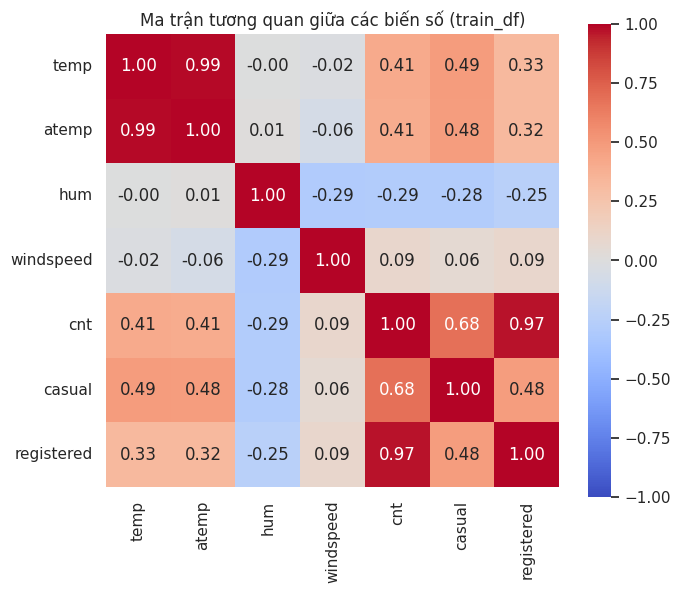

Correlation temp vs atemp: 0.992


In [9]:
corr = train_df[["temp", "atemp", "hum", "windspeed", "cnt", "casual", "registered"]].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Ma trận tương quan giữa các biến số (train_df)")
plt.tight_layout()
plt.show()

print(f"Correlation temp vs atemp: {corr.loc['temp', 'atemp']:.3f}")

**Nhận xét:** tương quan `temp`–`atemp` = 0.992 (> 0.9) → nên loại bỏ 1 trong 2 biến (giữ `atemp` vì phản ánh cảm nhận thực tế của người dùng hơn) để tránh đa cộng tuyến khi dùng mô hình tuyến tính như Logistic Regression.

### A3.4. Phân phối lớp (class balance)

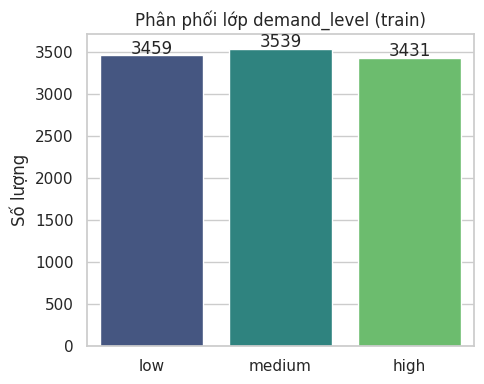

In [10]:
counts = train_df["demand_level"].map(DEMAND_LEVEL_LABELS).value_counts().reindex(label_names)

plt.figure(figsize=(5, 4))
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette="viridis", legend=False)
plt.title("Phân phối lớp demand_level (train)")
plt.ylabel("Số lượng")
plt.xlabel("")
for i, v in enumerate(counts.values):
    plt.text(i, v + 20, str(v), ha="center")
plt.tight_layout()
plt.show()

**Nhận xét:** nhờ chia theo quantile 33/67 trên `train_df`, 3 lớp gần như cân bằng tuyệt đối (low 3459, medium 3539, high 3431; chênh lệch < 2%).

## Kết luận EDA

- Dữ liệu sạch, không có NaN hay dòng trùng; cần ghi nhận 165 giờ bị thiếu trong chuỗi thời gian.
- Ngưỡng phân lớp: `low = 56.0`, `high = 176.0` (quantile 33%/67% của `cnt` trên `train_df`); 3 lớp cân bằng.
- Thứ tự ưu tiên feature theo EDA: `hr` > `temp`/`atemp` > `hum` >> `windspeed`; `temp` và `atemp` đa cộng tuyến (0.992) nên chỉ giữ một.
- Hai nhóm người dùng có pattern khác nhau rõ rệt (registered: giờ đi làm; casual: giải trí cuối tuần) → `hr` và `workingday` là thông tin quan trọng.
- Metric đề xuất: vì 3 lớp cân bằng, accuracy vẫn dùng được, nên theo dõi thêm macro-F1 và confusion matrix (dự kiến lớp medium dễ bị nhầm với cả low và high vì nằm giữa).

# Phần B — Tiền xử lý

## B1. Tạo feature lag

Tính trên toàn bộ chuỗi `df` (đã sort, trước khi chia tập) để các dòng đầu tập val/test vẫn lấy đúng giá trị từ cuối tập liền trước.

- `lag_1h`: số lượt thuê của giờ liền trước
- `same_hour_prev`: số lượt thuê cùng giờ của ngày hôm trước

Dòng nào không có giờ liền kề thật (do các giờ bị thiếu ở A1) nhận NaN thay vì lấy nhầm giá trị. NaN **chưa được xử lý** ở bước này.

In [11]:
df["time_full"] = df["dteday"] + pd.to_timedelta(df["hr"], unit="h")
df["gap_hours"] = df["time_full"].diff().dt.total_seconds() / 3600

df["lag_1h"] = df["cnt"].shift(1)
df.loc[df["gap_hours"] != 1, "lag_1h"] = np.nan

same_hour_prev_map = df.set_index("time_full")["cnt"]
prev_day_time = df["time_full"] - pd.Timedelta(days=1)
df["same_hour_prev"] = prev_day_time.map(same_hour_prev_map)

lag_cols = ["lag_1h", "same_hour_prev"]
print("NaN count:")
print(df[lag_cols].isna().sum())

NaN count:
lag_1h             76
same_hour_prev    160
dtype: int64


## B2. Gán nhãn `demand_level`

Dùng lại `low`, `high` và hàm `assign_demand_level` đã định nghĩa ở A2 (tính từ `train_df`), áp dụng cho toàn bộ `df`.

In [12]:
df["demand_level"] = df["cnt"].apply(assign_demand_level)
df["demand_level"].map(DEMAND_LEVEL_LABELS).value_counts()

demand_level
high      7411
low       5158
medium    4810
Name: count, dtype: int64

## B3. Mã hóa biến

- **Cyclical encoding (sin/cos)** cho `hr` (chu kỳ 24), `mnth` (12), `weekday` (7): để mô hình hiểu giờ 23 và giờ 0 là liền kề nhau.
- **One-hot** cho `season`, `weathersit` với `drop_first=True` (tránh đa cộng tuyến hoàn hảo giữa các cột dummy; mức 1 là mốc tham chiếu).
- `holiday`, `workingday` đã là nhị phân, giữ nguyên.

In [13]:
for col, period in CYCLICAL_FEATURES.items():
    df[f"{col}_sin"] = np.sin(2 * np.pi * df[col] / period)
    df[f"{col}_cos"] = np.cos(2 * np.pi * df[col] / period)

df = pd.get_dummies(df, columns=ONE_HOT_FEATURES, prefix=ONE_HOT_FEATURES, drop_first=True)
onehot_cols = [c for c in df.columns if c.startswith(tuple(f"{f}_" for f in ONE_HOT_FEATURES))]
print("One-hot columns:", onehot_cols)

One-hot columns: ['season_2', 'season_3', 'season_4', 'weathersit_2', 'weathersit_3', 'weathersit_4']


## B4. Loại bỏ cột không dùng làm feature

- `temp`: tương quan 0.992 với `atemp` (xem A3.3), giữ `atemp`.
- `casual`, `registered`: cấu thành trực tiếp `cnt` → rò rỉ nhãn; `cnt`: đã dùng để tạo nhãn.
- `instant` (chỉ số dòng), `dteday`, `yr`: mã hóa mốc thời gian tuyệt đối, dễ khiến mô hình học theo thứ tự thời gian thay vì quy luật lặp lại khi chia tập theo thời gian.
- `hr`, `mnth`, `weekday`: đã được thay bằng phiên bản sin/cos; `time_full`, `gap_hours`: cột phụ.

In [14]:
df = df.drop(columns=["temp", "instant", "dteday", "casual", "registered", "cnt", "yr",
                      "hr", "mnth", "weekday", "time_full", "gap_hours"])
print(df.columns.tolist())

['holiday', 'workingday', 'atemp', 'hum', 'windspeed', 'lag_1h', 'same_hour_prev', 'demand_level', 'hr_sin', 'hr_cos', 'mnth_sin', 'mnth_cos', 'weekday_sin', 'weekday_cos', 'season_2', 'season_3', 'season_4', 'weathersit_2', 'weathersit_3', 'weathersit_4']


## B5. Chia tập train/val/test và chuẩn hóa

Dùng lại chỉ số chia `n_train`, `n_val` từ A2 nên tập `train` trùng khớp với `train_df` đã dùng để tính ngưỡng. `StandardScaler` chỉ fit trên train rồi áp dụng cho val; tập test chưa được dùng ở giai đoạn này.

In [15]:
final_feature_columns = (
    [f"{c}_sin" for c in CYCLICAL_FEATURES]
    + [f"{c}_cos" for c in CYCLICAL_FEATURES]
    + ["holiday", "workingday", "atemp", "hum", "windspeed"]
    + onehot_cols
    + lag_cols
)

train = df.iloc[:n_train].copy()
val = df.iloc[n_train:n_train + n_val].copy()
test = df.iloc[n_train + n_val:].copy()

x_train = train[final_feature_columns]
y_train = train["demand_level"]

x_val = val[final_feature_columns]
y_val = val["demand_level"]

x_test = test[final_feature_columns]
y_test = test["demand_level"]

print(f"train: {len(train)} lines | val: {len(val)} lines | test: {len(test)} lines")
print(f"features: {len(final_feature_columns)}")
final_feature_columns

train: 10429 lines | val: 3475 lines | test: 3475 lines
features: 19


['hr_sin',
 'mnth_sin',
 'weekday_sin',
 'hr_cos',
 'mnth_cos',
 'weekday_cos',
 'holiday',
 'workingday',
 'atemp',
 'hum',
 'windspeed',
 'season_2',
 'season_3',
 'season_4',
 'weathersit_2',
 'weathersit_3',
 'weathersit_4',
 'lag_1h',
 'same_hour_prev']

In [16]:
scaler = StandardScaler()
x_train_scale = scaler.fit_transform(x_train)
x_val_scale = scaler.transform(x_val)

# Phần C — Feature selection

Sử dụng 3 phương pháp, Mutual Information (model-free), Gini Importance, Permutation Importance để chọn các feature ảnh hưởng nhất tới điểm chính xác

*Phần này chưa chạy: cần `model_rf` đã huấn luyện và xử lý NaN của các cột lag trước.*

In [ ]:
#model_rf = RandomForestClassifier(random_state=seed, n_estimators=300)
#model_rf.fit(x_train_fit, y_train_fit)

In [ ]:
mi_scores = mutual_info_classif(x_train, y_train, random_state=seed)
mi_series = pd.Series(mi_scores, index=final_feature_columns).sort_values(ascending=False)

# model_rf là mô hình Random Forest giả định đã được huẩn luyện trước 
# sau khi tiền xử lý, feature selection nhằm tìm ra các feature có độ ảnh hưởng
# cao để thử cải thiện mô hình 
# chạy feature selection trước khi hyperparameter tunnning
gini_series = pd.Series(model_rf.feature_importances_, index=final_feature_columns).sort_values(ascending=False)

perm_result = permutation_importance(
    model_rf, x_val, y_val, n_repeats=10, random_state=seed, scoring="f1_macro"
)
perm_series = pd.Series(perm_result.importances_mean, index=final_feature_columns).sort_values(ascending=False)

importance_df = pd.DataFrame({
    "mutual_info": mi_series,
    "gini": gini_series,
    "permutation": perm_series,
})
importance_df

In [ ]:
normalized = importance_df.apply(lambda col: col / col.max())
normalized["combined_score"] = normalized.mean(axis=1)
normalized = normalized.sort_values("combined_score", ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x=normalized["combined_score"], y=normalized.index, ax=ax)
ax.set_title("Combined feature importance (MI + Gini + Permutation, normalized)")
plt.tight_layout()
plt.show()

normalized

## Chọn tập feature rút gọn

In [ ]:
median_score = normalized["combined_score"].median()
selected_features = normalized[normalized["combined_score"] >= median_score].index.tolist()

print("So luong feature con lai:", len(selected_features), "/", len(final_feature_columns))
print(selected_features)